In [1]:
import numpy as np
import json

all_activations = np.load("activations.npy")
with open("activations_metadata.json") as f:
    metadata = json.load(f)

print(f"Activations shape: {all_activations.shape}")
print(f"Stories: {len(metadata)}")

Activations shape: (48, 43, 3584)
Stories: 48


In [2]:
biased_idx = [i for i, m in enumerate(metadata) if m["condition"] == "biased"]
neutral_idx = [i for i, m in enumerate(metadata) if m["condition"] == "neutral"]

biased_acts = all_activations[biased_idx]   # (24, 43, 3584)
neutral_acts = all_activations[neutral_idx]  # (24, 43, 3584)

print(f"Biased:  {biased_acts.shape}")
print(f"Neutral: {neutral_acts.shape}")

Biased:  (24, 43, 3584)
Neutral: (24, 43, 3584)


In [3]:
# Mean over the 24 stories, then subtract
bias_directions = biased_acts.mean(axis=0) - neutral_acts.mean(axis=0)
# shape: (43, 3584)

print(f"Bias directions shape: {bias_directions.shape}")
print(f"Norm at each layer (every 5th):")
for i in range(0, 43, 5):
    norm = np.linalg.norm(bias_directions[i])
    print(f"  Layer {i:2d}: {norm:.4f}")

Bias directions shape: (43, 3584)
Norm at each layer (every 5th):
  Layer  0: 3.1655
  Layer  5: 3.9341
  Layer 10: 6.8068
  Layer 15: 11.1530
  Layer 20: 15.7286
  Layer 25: 20.2398
  Layer 30: 29.5503
  Layer 35: 36.7827
  Layer 40: 50.2246


In [4]:
# Normalize each layer's direction to unit length
norms = np.linalg.norm(bias_directions, axis=1, keepdims=True)  # (43, 1)                                                                  
bias_directions_normalized = bias_directions / norms             # (43, 3584)                                                            

print("Norms after normalization (should all be 1.0):")
for i in range(0, 43, 5):
    norm = np.linalg.norm(bias_directions_normalized[i])
    print(f"  Layer {i:2d}: {norm:.6f}")

Norms after normalization (should all be 1.0):
  Layer  0: 1.000000
  Layer  5: 1.000000
  Layer 10: 1.000000
  Layer 15: 1.000000
  Layer 20: 1.000000
  Layer 25: 1.000000
  Layer 30: 1.000000
  Layer 35: 1.000000
  Layer 40: 1.000000


In [5]:
# Project every story onto the bias direction at each layer
# all_activations: (48, 43, 3584)
# bias_directions_normalized: (43, 3584)

projections = np.einsum("sld,ld->sl", all_activations, bias_directions_normalized)
# shape: (48, 43) — one scalar per story per layer

biased_proj = projections[biased_idx]   # (24, 43)
neutral_proj = projections[neutral_idx] # (24, 43)

print("Mean projection by condition (every 5th layer):")
print(f"{'Layer':>6}  {'Biased':>10}  {'Neutral':>10}  {'Gap':>10}")
for i in range(0, 43, 5):
    b = biased_proj[:, i].mean()
    n = neutral_proj[:, i].mean()
    print(f"{i:>6}  {b:>10.4f}  {n:>10.4f}  {b-n:>10.4f}")

Mean projection by condition (every 5th layer):
 Layer      Biased     Neutral         Gap
     0     -5.1364     -8.3018      3.1655
     5      0.9283     -3.0058      3.9341
    10     -3.8674    -10.6742      6.8068
    15    -31.1238    -42.2768     11.1529
    20    -35.6639    -51.3924     15.7286
    25    -31.7848    -52.0245     20.2398
    30    -23.7331    -53.2834     29.5503
    35    -77.8493   -114.6320     36.7827
    40    -90.5401   -140.7647     50.2246


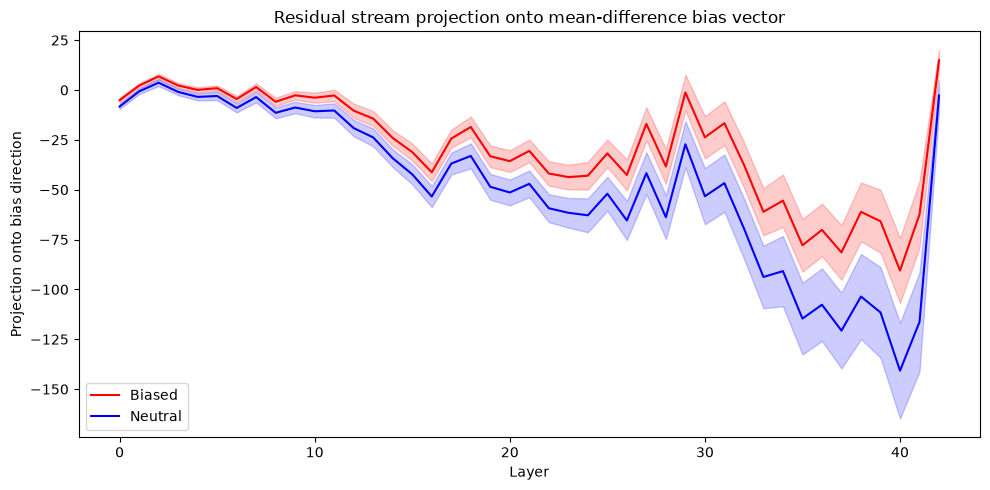

Saved bias_projection_by_layer.png


In [9]:
import matplotlib.pyplot as plt

layers = range(43)
biased_mean = biased_proj.mean(axis=0)
neutral_mean = neutral_proj.mean(axis=0)
biased_std = biased_proj.std(axis=0)
neutral_std = neutral_proj.std(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(layers, biased_mean, label="Biased", color="red")
plt.plot(layers, neutral_mean, label="Neutral", color="blue")
plt.fill_between(layers, biased_mean - biased_std, biased_mean + biased_std, alpha=0.2, color="red")
plt.fill_between(layers, neutral_mean - neutral_std, neutral_mean + neutral_std, alpha=0.2, color="blue")
plt.xlabel("Layer")
plt.ylabel("Projection onto bias direction")
plt.title("Residual stream projection onto mean-difference bias vector")
plt.legend()
plt.tight_layout()
plt.savefig("bias_projection_by_layer.png", dpi=150)
plt.show()
print("Saved bias_projection_by_layer.png")

In [10]:
np.save("bias_directions.npy", bias_directions_normalized)
print("Saved bias_directions.npy")

Saved bias_directions.npy
